In [31]:
# arxiv 4.x는 Search.results() 가 제거되어 langchain-community와 호환 안 됨 → 2.1.3 고정
%pip install -U duckduckgo-search langchain-community "arxiv==2.1.3"


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
from dotenv import load_dotenv

load_dotenv()

True

In [33]:
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    azure_deployment='gpt-4o-2024-11-20',
    api_version='2024-08-01-preview'
)

small_llm = AzureChatOpenAI(
    azure_deployment='gpt-4.1-mini',
    api_version='2024-08-01-preview'
)

In [34]:
small_llm.invoke("test")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 14, 'engine_ttft_ms': 62, 'engine_ttlt_ms': 199, 'pre_inference_ms': 98, 'service_tbt_ms': 14, 'service_ttft_ms': 258, 'service_ttlt_ms': 393, 'total_duration_ms': 301, 'user_visible_ttft_ms': 160}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_a7294185dc', 'id': 'chatcmpl-DnhV62QDWf7YfHSLR8dX4ZfZlSi0T', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'sel

In [35]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """ 숫자 a와 b를 더합니다. """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """ 숫자 a와 b를 곱합니다. """
    return a * b

In [36]:
from langchain_community.tools import DuckDuckGoSearchResults

search_tool = DuckDuckGoSearchResults()

In [37]:
# langchain 1.x: load_tools가 langchain_community.agent_toolkits.load_tools 로 이동됨
from langchain_community.agent_toolkits.load_tools import load_tools

loaded_tool_list = load_tools(["arxiv"])

In [38]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",  # 라이브러리 파라미터명 자체가 오타(sercret)라 그대로 써야 함
)

api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

/var/folders/xt/y_17jz6n3p77v5p6cbm1tstr0000gn/T/ipykernel_92767/4133888702.py:7: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/xt/y_17jz6n3p77v5p6cbm1tstr0000gn/T/ipykernel_92767/4133888702.py:13: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [39]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x120895910>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x120895910>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x120895910>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x120895910>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x120895910>)]

In [40]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

# 7장에서 DB를 만들 때와 동일한 임베딩/컬렉션명을 써야 함
# (collection_name='real_estate_tax' 는 비어 있고, 실제 48개 벡터는 'real_estate_tax_collection' 에 있음)
embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='real_estate_tax_collection',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='종합부동산세(종부세) 세율, 공제, 공정시장가액비율 등 관련 법령 정보를 검색합니다. 부동산 세금 계산 질문에 사용하세요.',
)

In [41]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [42]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [43]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [44]:
from langgraph.graph import END

def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return END

In [45]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [46]:
from langgraph.graph import START

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)

graph_builder.add_edge('tools', 'agent')

In [47]:
graph = graph_builder.compile()

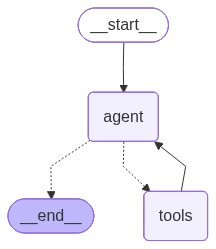

In [48]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
from langchain_core.messages import HumanMessage

query = "집이 15억일때 종합 부동산 세를 계산해"
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

집이 15억일때 종합 부동산 세를 계산해
================================== Ai Message ==================================
Tool Calls:
  real_estate_tax_retriever (call_RmBw3Xd0SzaSW6fndva3P6QV)
 Call ID: call_RmBw3Xd0SzaSW6fndva3P6QV
  Args:
    query: 종합부동산세 계산 기준 및 세율 15억 주택
================================= Tool Message =================================
Name: real_estate_tax_retriever

납세의무자가 2주택 이하를 소유한 경우

| 과세표준              | 세율                                  |
|---------------------|-------------------------------------|
| 3억 원 이하           | 1천분의 5                              |
| 3억 원 초과 6억 원 이하 | 150만 원 + (3억 원을 초과하는 금액의 1천분의 7)  |
| 6억 원 초과 12억 원 이하 | 360만 원 + (6억 원을 초과하는 금액의 1천분의 10) |
| 12억 원 초과 25억 원 이하 | 960만 원 + (12억 원을 초과하는 금액의 1천분의 13)|
| 25억 원 초과 50억 원 이하 | 2천650만 원 + (25억 원을 초과하는 금액의 1천분의 15)|
| 50억 원 초과 94억 원 이하 | 6천400만 원 + (50억 원을 초과하는 금액의 1천분의 20)|
| 94억 원 초과          | 1억 5천200만 원 + (94억 원을 초과하는